# Demonstration of OBIWAN-API

This is a quick demo of using the OBIWAN-API. The code here is not for production. No error handling code was added in this notebook.


In [ ]:
# @title 1. Helper function

import requests
from typing import Any
from enum import Enum

class ObiwanEndpoints(Enum):
  GET_STATE_MAP = "biomass_map"
  GET_CHANGE_MAP = "change_map"
  POST_STOCK_ESTIMATION = "estimate_biomass_state_geojson"
  POST_CHANGE_ESTIMATION = "estimate_biomass_change_geojson"
  POST_ANNUAL_ESTIMATION = "annual_biomass_state_geojson"
  POST_CHANGE_ADDITIONALITY = "estimate_biomass_additionality_geojson"

class ObiwanClient:
  def __init__(self, service_url):
    """
    Initialize the API client with a base URL.

    Parameters:
    base_url (str): The base URL for the API.
    """
    self.base_url = service_url

  def _get(self, endpoint, params=None):
    """
    Send a GET request to the API.

    Parameters:
    endpoint (str): The API endpoint.
    params (dict): The parameters to be sent in the query string (default is None).

    Returns:
    response (dict): The JSON response from the API.
    """
    url = f"{self.base_url}/{endpoint}"

    response = requests.get(url, params=params)
    return response.json()

  def _post(self, endpoint, json=None, headers=None):
    """
    Send a POST request to the API.

    Parameters:
    endpoint (str): The API endpoint.
    data (dict): The data to be sent in the body of the POST request (default is None).
    headers (dict): The headers to be sent with the POST request (default is None).

    Returns:
    response (dict): The JSON response from the API.
    """
    url = f"{self.base_url}/{endpoint}"
    response = requests.post(url, json=json, headers=headers)
    return response.json()

  def get_biomass_map(self, year: int, use_calibration:bool = False):
    return self._get(f"{ObiwanEndpoints.GET_STATE_MAP.value}/{year}",
                     params={"use_calibration": use_calibration})

  def get_change_map(self, start_year: int, end_year:int, use_calibration:bool = False):
    return self._get(f"{ObiwanEndpoints.GET_CHANGE_MAP.value}/{start_year}/{end_year}",
                  params={"use_calibration": use_calibration})

  def estimate_biomass_stock(self, year:int, aoi: Any, use_calibration:bool = False):
    return self._post(f"{ObiwanEndpoints.POST_STOCK_ESTIMATION.value}/{year}?use_calibration={use_calibration}",
                      json=aoi)

  def estimate_biomass_change(self, start_year:int, end_year:int, aoi: Any, use_calibration:bool = False):
    return self._post(f"{ObiwanEndpoints.POST_CHANGE_ESTIMATION.value}/{start_year}/{end_year}?use_calibration={use_calibration}",
                    json=aoi)

  def annual_biomass_stock(self, aoi: Any, use_calibration: bool = False):
    return self._post(f"{ObiwanEndpoints.POST_ANNUAL_ESTIMATION.value}?use_calibration={use_calibration}",
                    json=aoi)

  def estimate_biomass_additionality(self, base_start_year:int,
                                     base_end_year:int,
                                     target_start_year:int,
                                     target_end_year:int,
                                     aoi: Any, use_calibration: bool = False):
    return self._post(f"{ObiwanEndpoints.POST_CHANGE_ADDITIONALITY.value}/{base_start_year}/{base_end_year}/{target_start_year}/{target_end_year}?use_calibration={use_calibration}",
                      json=aoi)

In [ ]:
# @title 2. Visualize OBIWAN Biomass Estimates
# @markdown First we create a MapViewer which is used to visualize the map and also help to define an area of interest.

from ipyleaflet import Map, TileLayer, basemaps, GeomanDrawControl, LayersControl

class MapViewer(Map):
    def __init__(self, center=(0,0), zoom=4, **kwargs):
        super().__init__(basemap=basemaps.Esri.WorldImagery,
                         center=center,
                         zoom=zoom,
                         **kwargs)

        self.draw_control = GeomanDrawControl()
        self.draw_control.polyline = {}
        self.draw_control.circlemarker = {}
        self.draw_control.rectangle = {}
        self.draw_control.polygon = {
            "pathOptions": {
                "fillColor": "#6be5c3",
                "color": "#6be5c3",
                "fillOpacity": 0.75
            }
        }

        self.scroll_wheel_zoom=True

        super().add_control(self.draw_control)

    def get_aoi(self):
        return self.draw_control.data

service_url = "https://obiwan-alabama-api-5026633953.us-west1.run.app"

# create a client object
client = ObiwanClient(service_url)

val = client.get_biomass_map(2021, True)
m = MapViewer(center=(32.897, -86.737), zoom=8, layout={'height': '800px'})
m.add_layer(TileLayer(url=val["url"], name='Biomass 2021'))
m.add_control(LayersControl(position='topright'))
m


MapViewer(center=[32.897, -86.737], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title'…

## 3. Biomass Estimation for Area of Interest

In [ ]:
# @title Select year of interest

import ipywidgets as widgets
from IPython.display import display

year_slider = widgets.IntSlider(
  value=2009,
  min=1999,
  max=2023,
  step=2,
  description='Year:',
  continuous_update=False
)

calibration_checkbox_biomass = widgets.Checkbox(
    value=False,
    description='with calibration',
    disabled=False
)

display(widgets.HBox([year_slider, calibration_checkbox_biomass]))

In [ ]:
# @title Estimation result
import pandas as pd
pd.set_option('display.precision', 2)

aoi = {
  "type": "FeatureCollection",
  "features": []
}

aoi["features"] = m.get_aoi()

estimates = client.estimate_biomass_stock(year_slider.value, aoi, calibration_checkbox_biomass.value)

pd.DataFrame([estimates])

,AGBD,area_ha,asset_version,stdAGBD,use_calibration,year
0,142.8,107394.59,1.0,9.84,False,2009


## 4. Temporal Trend of Biomass

This shows the annual biomass change for the user defined area above. It uses Seaborn library for the scatter plot.

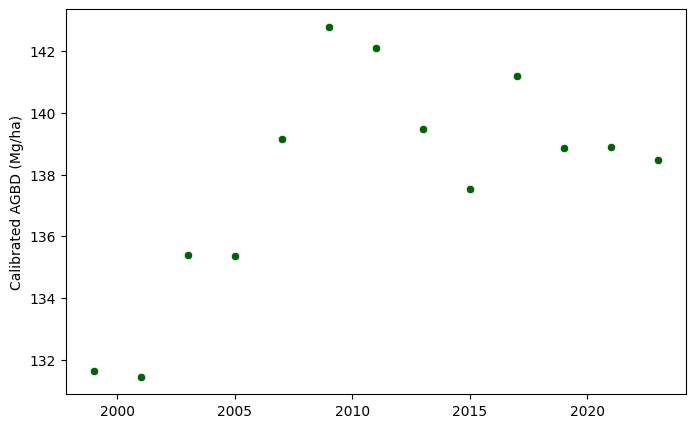

In [ ]:
# @title Temporal trend of AGBD


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

aoi = {
  "type": "FeatureCollection",
  "features": []
}

aoi["features"] = m.get_aoi()

estimates = client.annual_biomass_stock(aoi, calibration_checkbox_biomass.value)

estimates = pd.DataFrame(estimates)

plt.figure(figsize=(8,5))

ax = sns.scatterplot(data=estimates, x="Year", y="AGBD", color="darkgreen", marker="o")
ax.set(xlabel="", ylabel="Calibrated AGBD (Mg/ha)")

plt.show()


## 5. Change Estimation for Area of Interest

## 5.1. Single Temporal Window

In [ ]:
# @title Select Time Period of Interest

year_range = widgets.IntRangeSlider(
    value=[1999, 2023],
    min=1999,
    max=2023,
    step=2,
    description='Year Range:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='360px')
)

calibration_checkbox_change = widgets.Checkbox(
    value=True,
    description='with calibration',
    disabled=False
)

display(widgets.HBox([year_range, calibration_checkbox_change]))

In [ ]:
# @title Estimated change

aoi = {
  "type": "FeatureCollection",
  "features": []
}

aoi["features"] = m.get_aoi()

start_year, end_year = year_range.value
use_calibration = calibration_checkbox_change.value

estimates = pd.DataFrame([client.estimate_biomass_change(start_year, end_year, aoi, use_calibration)])

estimates

,start_year,end_year,asset_version,use_calibration,area_ha,dAGBD,stddAGBD
0,2007,2015,1.0,True,107394.59,15.42,0.9


## 5.2. Counterfactual

For simplicity, in this simple simulation of counterfactual analysis, each polygon drawn is considered as a separate entity. In full application, user can define the comparison unit as they like multiple polygon, or using different existing area of interests.

In [ ]:
# @title Select Temporal Window
year_range = widgets.IntRangeSlider(
    value=[1999, 2023],
    min=1999,
    max=2023,
    step=2,
    description='Year Range:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='360px')
)

calibration_checkbox_change = widgets.Checkbox(
    value=True,
    description='with calibration',
    disabled=False
)

display(widgets.HBox([year_range, calibration_checkbox_change]))

In [ ]:
# @title Estimation Results
import pandas as pd
pd.set_option('display.precision', 2)

def counter_factual():
  aoi = {
    "type": "FeatureCollection",
    "features": []
  }

  aois = m.get_aoi()

  start_year, end_year = year_range.value
  use_calibration = calibration_checkbox_change.value

  result = pd.DataFrame()

  for idx, aoi_item in enumerate(aois):
    aoi["features"] = [aoi_item]
    estimates = pd.DataFrame([client.estimate_biomass_change(start_year, end_year, aoi, use_calibration)])
    estimates["ID"] = idx + 1

    result = pd.concat([result, estimates])

  return result

estimates = counter_factual()

estimates

,start_year,end_year,asset_version,use_calibration,area_ha,dAGBD,stddAGBD,ID
0,1999,2023,1.0,True,107394.59,18.92,1.56,1


## 5.3. Additionality Over Time

In [ ]:
# @title Select Temporal Windows to Evaluate

year_range1 = widgets.IntRangeSlider(
    value=[1999, 2005],
    min=1999,
    max=2023,
    step=2,
    description='Base:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='360px')
)

year_range2 = widgets.IntRangeSlider(
    value=[2015, 2021],
    min=1999,
    max=2023,
    step=2,
    description='Target:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='360px')
)

calibration_checkbox_change = widgets.Checkbox(
    value=True,
    description='with calibration',
    disabled=False
)

display(widgets.HBox([widgets.VBox([year_range1, year_range2]), calibration_checkbox_change]))


In [ ]:
# @title Estimation Results

import pandas as pd

aoi = {
  "type": "FeatureCollection",
  "features": []
}

aoi["features"] = m.get_aoi()

use_calibration = calibration_checkbox_change.value

start_year1, end_year1 = year_range1.value
start_year2, end_year2 = year_range2.value

estimates = client.estimate_biomass_additionality(start_year1, end_year1,
                                                  start_year2, end_year2,
                                                  aoi, use_calibration)

additionality = pd.DataFrame([estimates], index=['Value'])
additionality.T



,Value
base_start_year,2007
base_end_year,2017
target_start_year,2011
target_end_year,2017
asset_version,1.0
use_calibration,True
area_ha,107394.59
dAGBD,-1.3
stddAGBD,0.19
